# 3D XEDS drift correction

Correct a slow SrTiO$_3$ XEDS spectrum-image scan against a fast 0°/90° HAADF
reference pair. The workflow is deliberately small:

1. build the reference,
2. automatically align the XEDS HAADF affine drift,
3. refine row-dependent residual drift with the publication strip ladder,
4. inspect the correction and regional metrics,
5. apply the same field to selected elemental maps.

`correct_affine()` is fully automatic. Strip and non-rigid refinement are
separate, user-configured stages because their settings depend on the sample,
signal, and scan speed.

## Environment

Install the reviewed paper API and latest published `quantem.widget` release
candidate. One notebook supports both interactive and static/report output:

```bash
python -m pip install --upgrade \
  "git+https://github.com/bobleesj/quantem.git@drift-paper"
python -m pip install --pre --upgrade \
  --index-url https://test.pypi.org/simple \
  --extra-index-url https://pypi.org/simple quantem.widget
```

## Data

Download the [raw SrTiO₃ and XEDS data](https://drive.google.com/drive/folders/1apvB4X4YWgHTeJzBZuLv9TwZRwk0YV8m?usp=sharing)
and place the three EMD files in `data/srtio3_xeds/`. The shared folder
contains only original acquisitions; this notebook derives the energy-window
maps and correction results locally.

## Inspect the automatically selected compute backend

In [1]:
from pathlib import Path

import quantem.widget as qw
from quantem.imaging import DriftCorrection, read_emd_eds
from quantem.imaging.drift import StripPass
from quantem.widget import Show2D

# Raw EMDs and locally generated AutoSerialized results share DATA.
DATA = Path("data/srtio3_xeds")
REFERENCE_RESULT = DATA / "reference_drift.zip"
EDS_RESULT = DATA / "eds_drift.zip"
PIXEL_SIZE_NM = 6.74 / 2048

In [2]:
# Interactive is the recommended default. False uses static/report rendering.
INTERACTIVE = True
VIEW_MODE = "interactive" if INTERACTIVE else "static"
WIDGET_MODE = "interactive" if INTERACTIVE else "report"

qw.profile()

quantem.widget  0.0.1rc37
  install       published package
quantem.gpu     0.0.1rc6
  install       source override (differs from installed metadata)
quantem         0.1.9
torch           2.13.0  device=cuda (NVIDIA RTX PRO 6000)
GPUs            1 visible (CUDA_VISIBLE_DEVICES=0)
  GPU0           25.8 used / 102 GB  (76 free)
  torch pool    0.0 live / 0.0 reserved GB
python          3.14.6


## 1. Build the reference

The fast orthogonal HAADF pair defines the fixed geometry. A single
`correct_affine()` call prepares and solves the reference automatically.

In [3]:
reference = DriftCorrection.from_emd(
    DATA / "0047_20260709_1134_STEM_HAADF_15.0_Mx_6.74_nm_Diffraction.emd",
    DATA / "0046_20260709_1134_STEM_HAADF_15.0_Mx_6.74_nm_Diffraction.emd",
    verbose=False,
)

### Align the reference scans automatically

In [4]:
reference.correct_affine(
    show_combined=False,
    show_scans=False,
    show_knots=False,
    verbose=False,
)

### Inspect the reference before and after affine correction

The reference must be trustworthy before it is used to correct XEDS. The
report view keeps the raw and affine-corrected scans in the same acquisition
frame so edge coverage and atomic-column registration can be checked directly.

  Display bin 3×: 2560×2560 → 853×853 (16 MB preview; full-res detail streams on zoom)


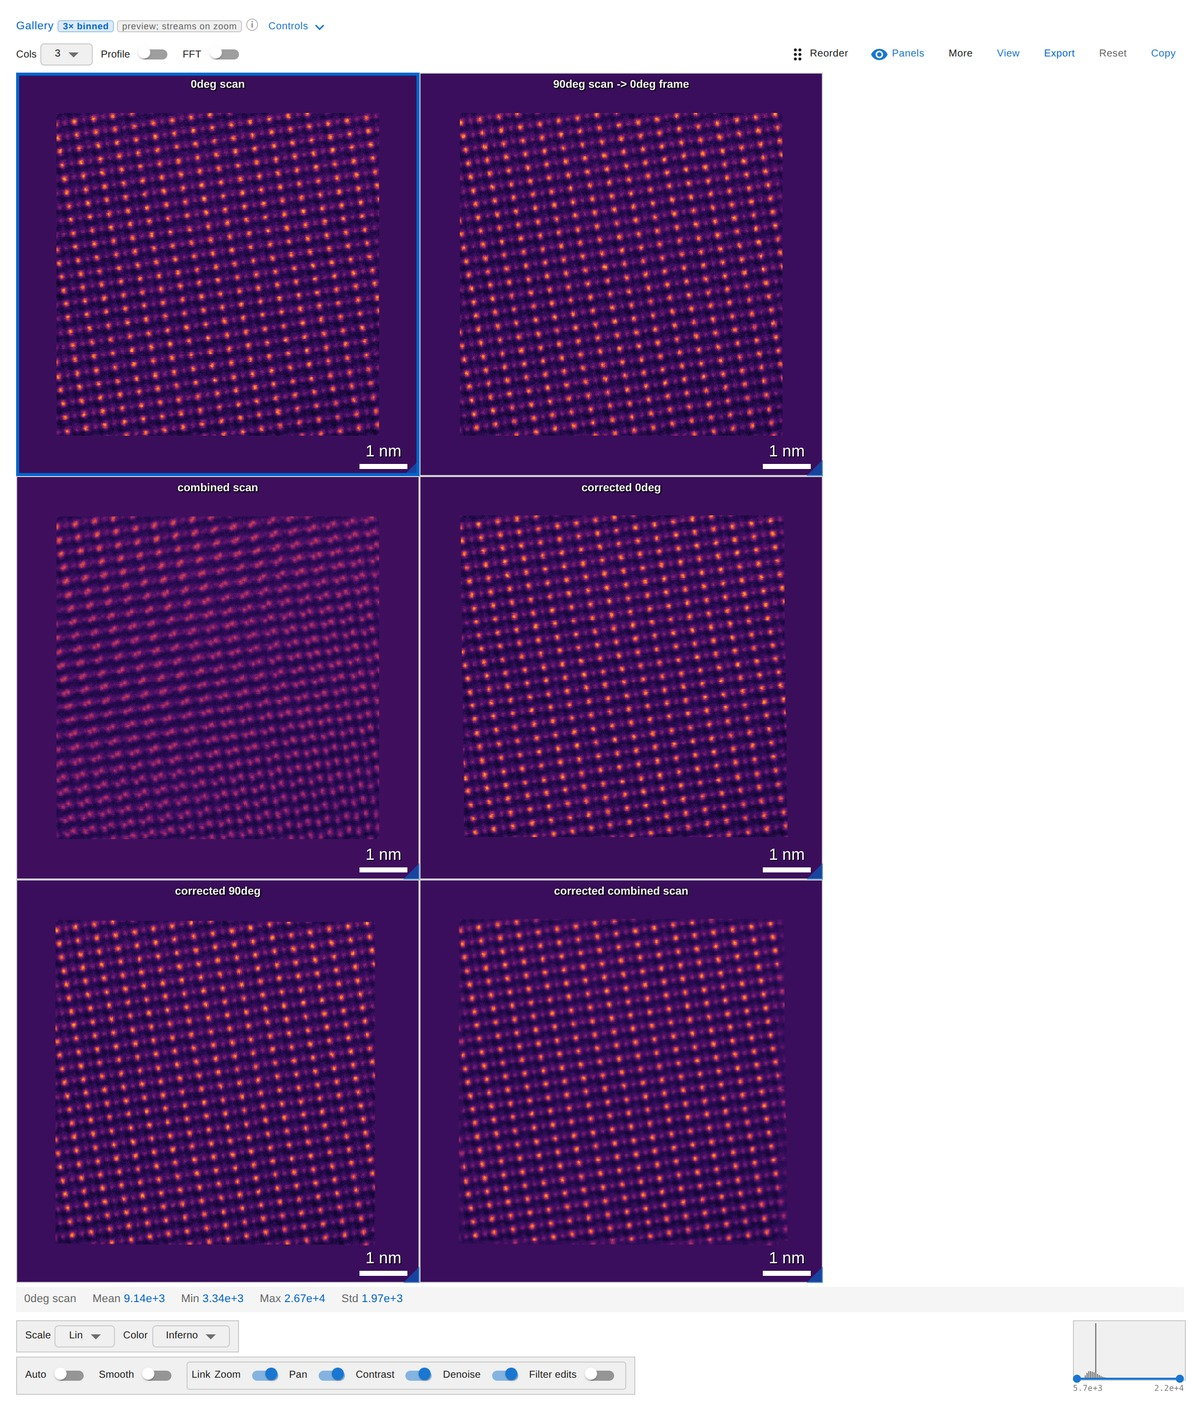

In [5]:
reference.show(mode=VIEW_MODE)

## 2. Correct the XEDS scan

The automatic affine search captures the large overall drift. The three strip
passes below are the publication recipe for the residual left by this specific
microscope scan.

In [6]:
eds = read_emd_eds(
    DATA / "0048_20260709_1134_SI_HAADF_15.0_Mx_6.74_nm_Diffraction.emd",
    energy_windows={
        "Ti K": (4.30, 4.80),
        "Sr L": (1.70, 1.95),
    },
    verbose=False,
)

eds_correction = DriftCorrection.from_reference(
    reference,
    eds["haadf"],
    scan_direction_degrees=eds["scan_rotation_deg"],
)


### Align the overall affine drift automatically

In [7]:
eds_correction.correct_affine(
    show_combined=False,
    show_scans=False,
    show_knots=False,
    verbose=False,
)

### Apply the publication row-dependent strip refinement

These settings reproduce this dataset; they are not universal defaults. Change
them when the residual drift, signal level, or scan speed differs.

In [8]:
STRIP_PASSES = [
    StripPass(
        num_strips=24,
        smoothing_sigma=12.0,
        max_column_shift=80,
        max_row_shift=8,
    ),
    StripPass(
        num_strips=24,
        smoothing_sigma=12.0,
        max_column_shift=12,
        max_row_shift=3,
    ),
    StripPass(
        num_strips=64,
        smoothing_sigma=6.0,
        max_column_shift=6,
        max_row_shift=2,
        update_fraction=0.8,
    ),
]
eds_correction.correct_strip(
    passes=STRIP_PASSES,
    show_combined=False,
    show_scans=False,
    show_knots=False,
    verbose=False,
)

## 3. Inspect the correction

  Display bin 3×: 2560×2560 → 853×853 (16 MB preview; full-res detail streams on zoom)


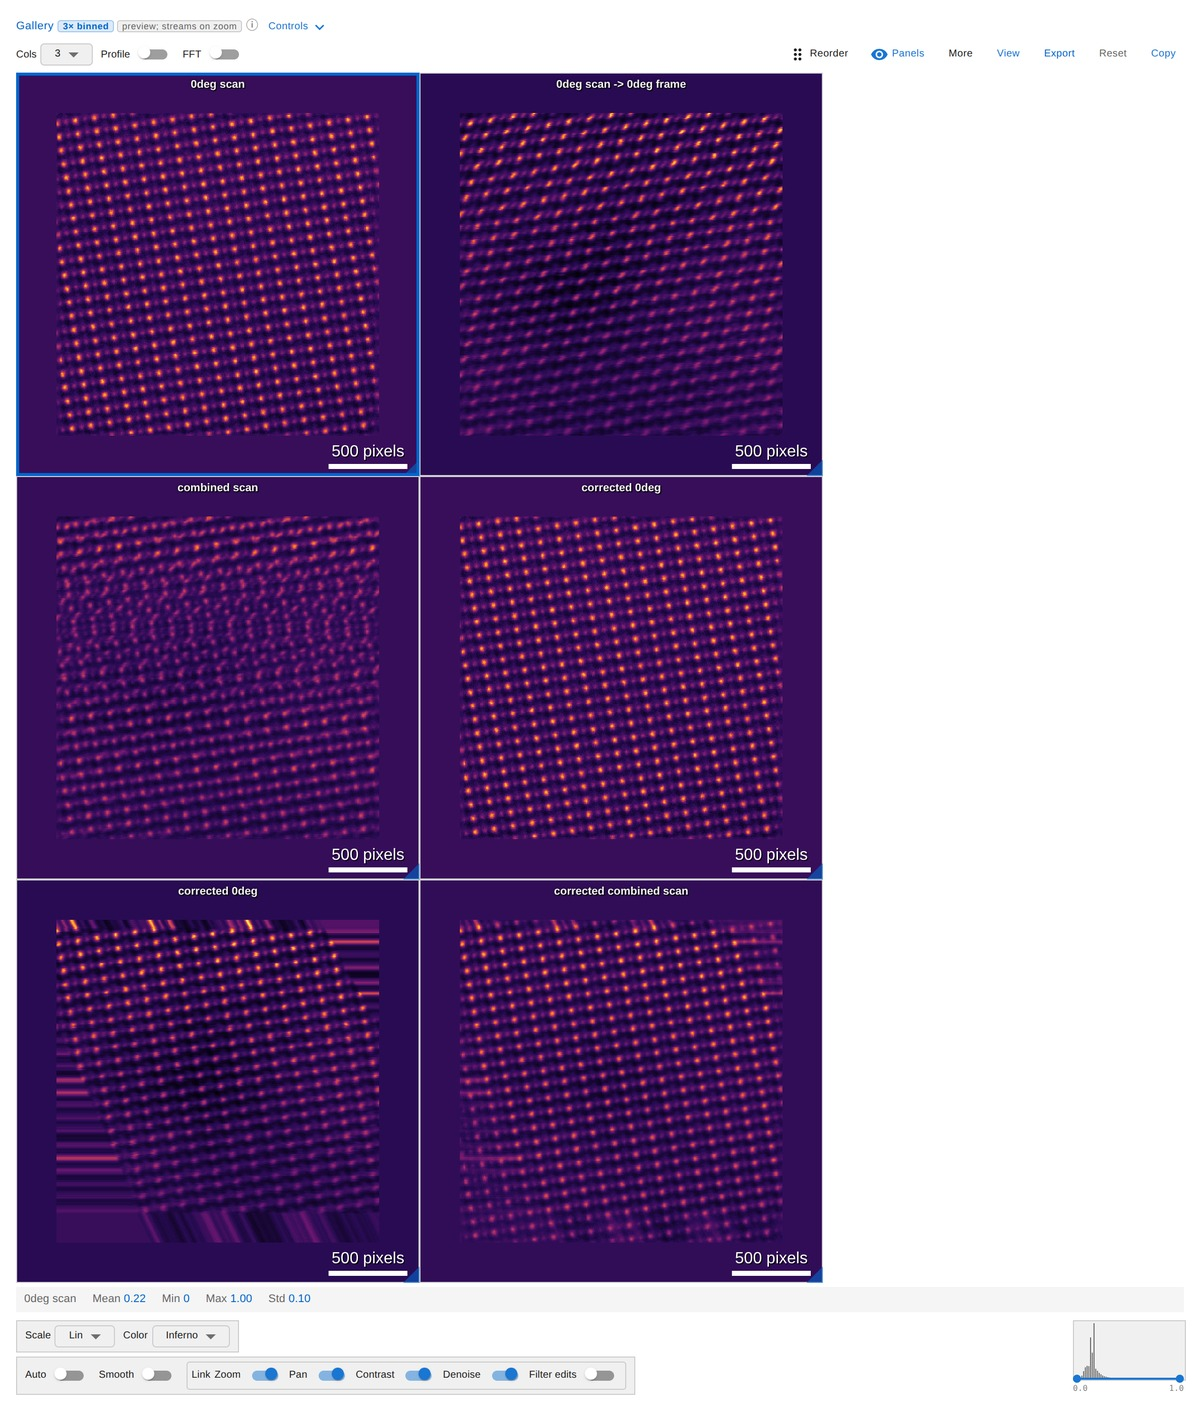

In [9]:
eds_correction.show(mode=VIEW_MODE)

## 4. Verify regional alignment

`report()` compares every completed checkpoint on one fixed common mask.
The returned object renders as a clean notebook table, so it is easy to inspect or
capture in a screenshot. Regional values matter: a global score can hide a poor
bottom-of-scan correction.

In [10]:
eds_correction.report()

,Common NCC,Top third,Middle third,Bottom third,Coverage
Fixed-reference stage,,,,,
before,-0.012484,-0.054496,-0.118632,0.321504,0.757306
affine,0.693177,0.717662,0.748004,0.624687,0.757306
strip,0.853970,0.912546,0.863963,0.828974,0.757306


## 5. Apply the same correction to elemental maps

The drift field is learned from HAADF and applied unchanged to the Ti K and
Sr L count maps extracted directly from the raw SpectrumStream.

denoise: anscombe σ=8 (set denoise='none' for raw counts)


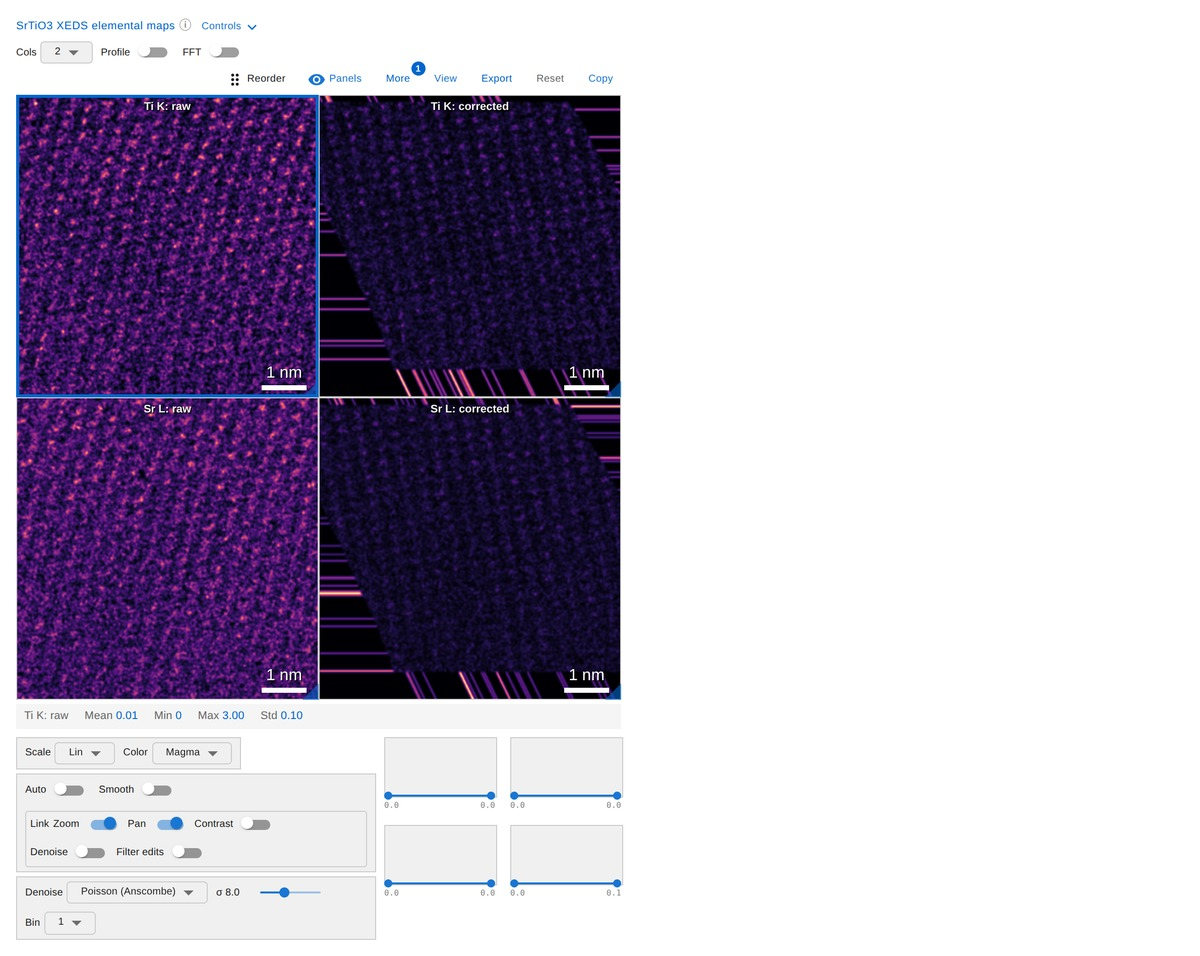

In [11]:
selected = list(eds["window_maps"].items())
corrected_maps = [
    eds_correction.apply_correction(image, image_index=1) for _, image in selected
]

chemistry_view = Show2D(
    [image for pair in zip((image for _, image in selected), corrected_maps) for image in pair],
    labels=[label for name, _ in selected for label in (f"{name}: raw", f"{name}: corrected")],
    title="SrTiO3 XEDS elemental maps",
    cmap="magma",
    ncols=2,
    sampling=PIXEL_SIZE_NM,
    units="nm",
    link_contrast=False,
    denoise=["anscombe"] * 4,
    denoise_sigma=[8.0] * 4,
    show_denoise=True,
    ui_mode=WIDGET_MODE,
)
chemistry_view

## 6. Save the full solved objects

AutoSerialize the reference pair and the registered XEDS correction next to
the raw data. The energy-window maps are derived from the raw SpectrumStream
above and can be regenerated whenever needed.

In [12]:
DATA.mkdir(parents=True, exist_ok=True)
reference.save(REFERENCE_RESULT, mode="o")
eds_correction.save(EDS_RESULT, mode="o")
print(f"Reference: {REFERENCE_RESULT}")
print(f"EDS:       {EDS_RESULT}")

Reference: data/srtio3_xeds/reference_drift.zip
EDS:       data/srtio3_xeds/eds_drift.zip


## Continue with advanced tutorials

- **Explicit affine search:** `advanced/2d_affine_explicit_srtio3.ipynb`
- **Non-rigid safety checks:** `advanced/2d_nonrigid_safety_ws2.ipynb`
- **WS₂ affine diagnostics:** `advanced/2d_affine_diagnostics_ws2_0070_0071.ipynb`

## Reproduce this notebook

From the paper repository:

```bash
conda run -n live-env python tutorials/template/build_3d_xeds_tutorial.py
```

Use `--no-execute` to regenerate only the notebook source.